In [1]:
import sys

print("Python being used:")
print(sys.executable)

from ultralytics import YOLO

print("YOLO is working successfully!")

Python being used:
d:\PROJECTS\ALS project\traffic_env\Scripts\python.exe
YOLO is working successfully!


In [2]:
from pathlib import Path

# Dataset location
DATASET_PATH = Path(r"D:\PROJECTS\ALS project\archive")

# Check dataset
print("Dataset path:")
print(DATASET_PATH)

print("\nDataset exists:", DATASET_PATH.exists())

# Check folders
for folder in ["train", "valid", "test"]:
    folder_path = DATASET_PATH / folder
    print(f"{folder}: {folder_path.exists()}")

# Count images
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for folder in ["train", "valid", "test"]:
    image_folder = DATASET_PATH / folder / "images"

    if image_folder.exists():
        images = [
            f for f in image_folder.iterdir()
            if f.suffix.lower() in extensions
        ]
        print(f"{folder} images: {len(images)}")
    else:
        print(f"{folder} images folder not found")

Dataset path:
D:\PROJECTS\ALS project\archive

Dataset exists: True
train: True
valid: True
test: True
train images: 7556
valid images: 1072
test images: 812


In [3]:
from pathlib import Path
import yaml

# Path to data.yaml
yaml_path = DATASET_PATH / "data.yaml"

print("Reading:", yaml_path)

# Load YAML
with open(yaml_path, "r") as file:
    data = yaml.safe_load(file)

print("\nDataset configuration:")
print(data)

print("\nClasses:")
for i, name in enumerate(data["names"]):
    print(i, "->", name)

print("\nNumber of classes:", data["nc"])

Reading: D:\PROJECTS\ALS project\archive\data.yaml

Dataset configuration:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 7, 'names': ['bicycle', 'bus', 'car', 'motorbike', 'rickshaw', 'truck', 'van'], 'roboflow': {'workspace': 'object-detection-sn8ac', 'project': 'ai-traffic-system', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/object-detection-sn8ac/ai-traffic-system/dataset/1'}}

Classes:
0 -> bicycle
1 -> bus
2 -> car
3 -> motorbike
4 -> rickshaw
5 -> truck
6 -> van

Number of classes: 7


In [4]:
from pathlib import Path

# Folders
train_images = DATASET_PATH / "train" / "images"
train_labels = DATASET_PATH / "train" / "labels"

valid_images = DATASET_PATH / "valid" / "images"
valid_labels = DATASET_PATH / "valid" / "labels"

test_images = DATASET_PATH / "test" / "images"
test_labels = DATASET_PATH / "test" / "labels"


def check_dataset(image_folder, label_folder, name):
    image_files = list(image_folder.glob("*"))
    label_files = list(label_folder.glob("*.txt"))

    image_stems = {f.stem for f in image_files}
    label_stems = {f.stem for f in label_files}

    missing_labels = image_stems - label_stems
    extra_labels = label_stems - image_stems

    print(f"\n===== {name} =====")
    print("Images:", len(image_files))
    print("Labels:", len(label_files))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(extra_labels))


check_dataset(train_images, train_labels, "TRAIN")
check_dataset(valid_images, valid_labels, "VALIDATION")
check_dataset(test_images, test_labels, "TEST")


===== TRAIN =====
Images: 7556
Labels: 7556
Images without labels: 0
Labels without images: 0

===== VALIDATION =====
Images: 1072
Labels: 1072
Images without labels: 0
Labels without images: 0

===== TEST =====
Images: 812
Labels: 812
Images without labels: 0
Labels without images: 0


In [5]:
from pathlib import Path

# Dataset folders
train_images = DATASET_PATH / "train" / "images"
train_labels = DATASET_PATH / "train" / "labels"

valid_images = DATASET_PATH / "valid" / "images"
valid_labels = DATASET_PATH / "valid" / "labels"

test_images = DATASET_PATH / "test" / "images"
test_labels = DATASET_PATH / "test" / "labels"


# Function to check images and labels
def check_dataset(image_folder, label_folder, name):

    image_files = [
        f for f in image_folder.iterdir()
        if f.is_file()
    ]

    label_files = list(label_folder.glob("*.txt"))

    image_stems = {
        f.stem for f in image_files
    }

    label_stems = {
        f.stem for f in label_files
    }

    missing_labels = image_stems - label_stems
    extra_labels = label_stems - image_stems

    print(f"\n===== {name} =====")
    print("Images:", len(image_files))
    print("Labels:", len(label_files))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(extra_labels))


# Check all three datasets
check_dataset(
    train_images,
    train_labels,
    "TRAIN"
)

check_dataset(
    valid_images,
    valid_labels,
    "VALIDATION"
)

check_dataset(
    test_images,
    test_labels,
    "TEST"
)


===== TRAIN =====
Images: 7556
Labels: 7556
Images without labels: 0
Labels without images: 0

===== VALIDATION =====
Images: 1072
Labels: 1072
Images without labels: 0
Labels without images: 0

===== TEST =====
Images: 812
Labels: 812
Images without labels: 0
Labels without images: 0


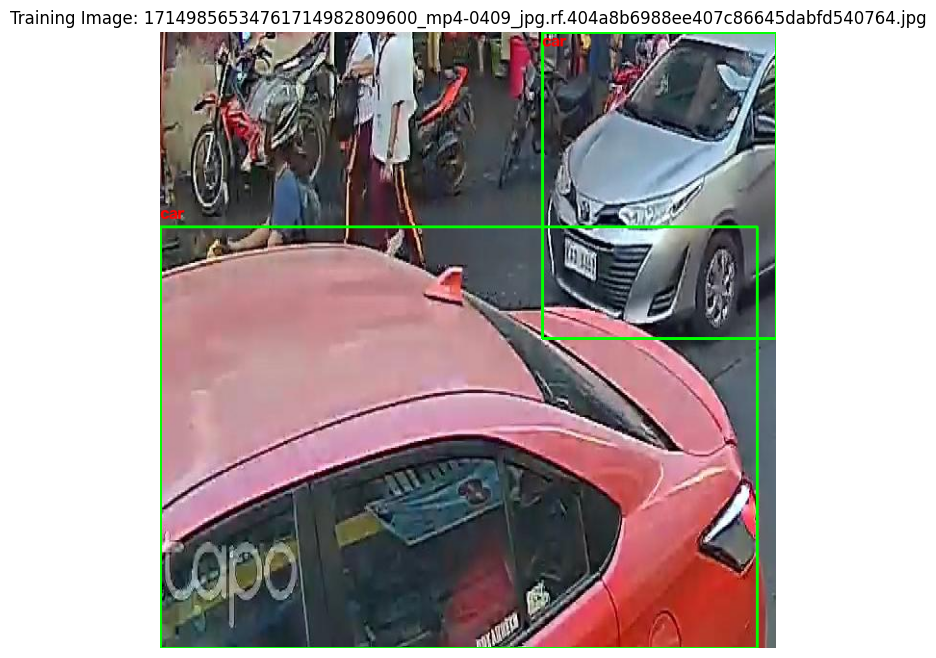

In [6]:
import random
import cv2
import matplotlib.pyplot as plt

# Get training images
image_files = [
    f for f in train_images.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
]

# Select a random image
image_path = random.choice(image_files)

# Corresponding YOLO label
label_path = train_labels / f"{image_path.stem}.txt"

# Read image
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

# Vehicle class names
class_names = [
    "bicycle",
    "bus",
    "car",
    "motorbike",
    "rickshaw",
    "truck",
    "van"
]

# Read YOLO labels
with open(label_path, "r") as file:
    labels = file.readlines()

# Draw bounding boxes
for line in labels:

    values = line.strip().split()

    class_id = int(values[0])

    x_center = float(values[1])
    y_center = float(values[2])
    box_width = float(values[3])
    box_height = float(values[4])

    # Convert YOLO coordinates to pixels
    x_center *= width
    y_center *= height
    box_width *= width
    box_height *= height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)

    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    # Draw box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Class label
    label = class_names[class_id]

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

# Display
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title(f"Training Image: {image_path.name}")
plt.show()

In [12]:
from pathlib import Path
import shutil
import random

# Original dataset
SOURCE = Path(r"D:\PROJECTS\ALS project\archive")

# Small dataset for quick testing
QUICK_DATASET = Path(r"D:\PROJECTS\ALS project\quick_dataset")

# Number of images
TRAIN_COUNT = 300
VAL_COUNT = 50

# Create folders
for folder in [
    QUICK_DATASET / "train" / "images",
    QUICK_DATASET / "train" / "labels",
    QUICK_DATASET / "valid" / "images",
    QUICK_DATASET / "valid" / "labels"
]:
    folder.mkdir(parents=True, exist_ok=True)

# Get training images
all_images = [
    f for f in (SOURCE / "train" / "images").iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

random.seed(42)
random.shuffle(all_images)

train_images = all_images[:TRAIN_COUNT]
val_images = all_images[TRAIN_COUNT:TRAIN_COUNT + VAL_COUNT]

def copy_dataset(images, split):
    for image in images:
        label = SOURCE / split / "labels" / f"{image.stem}.txt"

        shutil.copy2(
            image,
            QUICK_DATASET / split / "images" / image.name
        )

        if label.exists():
            shutil.copy2(
                label,
                QUICK_DATASET / split / "labels" / label.name
            )

copy_dataset(train_images, "train")

# Validation images come from original validation set
valid_source = [
    f for f in (SOURCE / "valid" / "images").iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

random.shuffle(valid_source)

copy_dataset(valid_source[:VAL_COUNT], "valid")

print("Quick dataset created successfully!")
print("Training images:", TRAIN_COUNT)
print("Validation images:", VAL_COUNT)
print("Location:", QUICK_DATASET)

Quick dataset created successfully!
Training images: 300
Validation images: 50
Location: D:\PROJECTS\ALS project\quick_dataset


In [13]:
from pathlib import Path
import yaml

QUICK_DATASET = Path(
    r"D:\PROJECTS\ALS project\quick_dataset"
)

quick_yaml = {
    "train": str(QUICK_DATASET / "train" / "images"),
    "val": str(QUICK_DATASET / "valid" / "images"),
    "nc": 7,
    "names": [
        "bicycle",
        "bus",
        "car",
        "motorbike",
        "rickshaw",
        "truck",
        "van"
    ]
}

yaml_path = QUICK_DATASET / "data.yaml"

with open(yaml_path, "w") as file:
    yaml.dump(
        quick_yaml,
        file,
        sort_keys=False
    )

print("Quick data.yaml created successfully!")
print()
print("Location:")
print(yaml_path)

print()
print("Configuration:")
print(quick_yaml)

Quick data.yaml created successfully!

Location:
D:\PROJECTS\ALS project\quick_dataset\data.yaml

Configuration:
{'train': 'D:\\PROJECTS\\ALS project\\quick_dataset\\train\\images', 'val': 'D:\\PROJECTS\\ALS project\\quick_dataset\\valid\\images', 'nc': 7, 'names': ['bicycle', 'bus', 'car', 'motorbike', 'rickshaw', 'truck', 'van']}


In [14]:
from ultralytics import YOLO
from pathlib import Path

# ============================================
# CELL 7 - QUICK YOLO TRAINING
# ============================================

QUICK_YAML = r"D:\PROJECTS\ALS project\quick_dataset\data.yaml"

# Load pretrained YOLO11 nano model
model = YOLO("yolo11n.pt")

print("=" * 60)
print("STARTING QUICK YOLO TRAINING")
print("=" * 60)

results = model.train(
    data=QUICK_YAML,

    # Quick training
    epochs=3,
    imgsz=416,
    batch=8,

    # Your computer has no CUDA GPU
    device="cpu",

    # CPU settings
    workers=0,

    # Stop early if validation doesn't improve
    patience=2,

    # Save model
    project=r"D:\PROJECTS\ALS project\runs",
    name="quick_traffic_model",

    verbose=True
)

print()
print("=" * 60)
print("TRAINING FINISHED")
print("=" * 60)

BEST_MODEL = Path(
    r"D:\PROJECTS\ALS project\runs"
) / "quick_traffic_model" / "weights" / "best.pt"

print("Best model:")
print(BEST_MODEL)

print()
print("Model exists:", BEST_MODEL.exists())

STARTING QUICK YOLO TRAINING
Ultralytics 8.4.117  Python-3.10.11 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\PROJECTS\ALS project\quick_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, mu

In [15]:
from ultralytics import YOLO
import os

model_path = r"D:\PROJECTS\ALS project\runs\quick_traffic_model\weights\best.pt"

model = YOLO(model_path)

print("Model loaded successfully!")
print("Classes:", model.names)

Model loaded successfully!
Classes: {0: 'bicycle', 1: 'bus', 2: 'car', 3: 'motorbike', 4: 'rickshaw', 5: 'truck', 6: 'van'}


In [18]:
import os

dataset_path = r"D:\PROJECTS\ALS project\quick_dataset"

print("Checking dataset...")
print(os.path.exists(dataset_path))

for root, dirs, files in os.walk(dataset_path):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    if image_files:
        print("\nImages found in:")
        print(root)

        print("Example images:")
        for f in image_files[:5]:
            print(" ", f)

Checking dataset...
True

Images found in:
D:\PROJECTS\ALS project\quick_dataset\train\images
Example images:
  104D5300_DSC_0037_JPG_jpg.rf.f36ce899d6b22cf335ef9fbd25a8ab5f.jpg
  104D5300_DSC_0039_JPG_jpg.rf.6505f8a639abacd76756196e22d784af.jpg
  130_jpg.rf.80978a0a81510f53bdd37d92c920b98d.jpg
  136_jpg.rf.b9722c3df4d8110dc6f4c0bcdb86b0a4.jpg
  15-minutes-of-heavy-traffic-noise-in-India-14-08-2022_mp4-0003_jpg.rf.ef7f1c566d8b34a32b5bf5c99f2eab3d.jpg

Images found in:
D:\PROJECTS\ALS project\quick_dataset\valid\images
Example images:
  17149856534761714982809600_mp4-0006_jpg.rf.410a07df184c64e9fd9c07c1f2c73f7c.jpg
  17149856534761714982809600_mp4-0144_jpg.rf.597245af086013adda812b01a69d81fb.jpg
  17149856534761714982809600_mp4-0160_jpg.rf.b34a4326bccd77c5ede9b65bbddfdc40.jpg
  17149856534761714982809600_mp4-0204_jpg.rf.81cc7a6237e6abfb2e7658b27450efb6.jpg
  17149856534761714982809600_mp4-0204_jpg.rf.9db8442e5a6c4e46937de00018fa0455.jpg


In [19]:
import os
import cv2
from ultralytics import YOLO

# ==========================================
# 1. LOAD TRAINED MODEL
# ==========================================

model_path = r"D:\PROJECTS\ALS project\runs\quick_traffic_model\weights\best.pt"

model = YOLO(model_path)

print("Model loaded successfully!")
print("Classes:", model.names)


# ==========================================
# 2. VALIDATION IMAGE FOLDER
# ==========================================

valid_path = r"D:\PROJECTS\ALS project\quick_dataset\valid\images"


# ==========================================
# 3. FIND FIRST VALIDATION IMAGE
# ==========================================

image_files = [
    f for f in os.listdir(valid_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

if not image_files:
    raise FileNotFoundError(
        "No images found in validation folder."
    )

image_path = os.path.join(
    valid_path,
    image_files[0]
)

print("\nTesting image:")
print(image_path)


# ==========================================
# 4. READ IMAGE
# ==========================================

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not read image.")

height, width = image.shape[:2]

print("Image size:", width, "x", height)


# ==========================================
# 5. RUN YOLO
# ==========================================

results = model.predict(
    source=image,
    imgsz=416,
    conf=0.25,
    verbose=False
)


# ==========================================
# 6. COUNT VEHICLES
# ==========================================

vehicle_counts = {}

total_vehicles = 0

for result in results:

    for box in result.boxes:

        class_id = int(box.cls[0])

        vehicle_name = model.names[class_id]

        confidence = float(box.conf[0])

        vehicle_counts[vehicle_name] = (
            vehicle_counts.get(vehicle_name, 0) + 1
        )

        total_vehicles += 1


# ==========================================
# 7. PRINT RESULTS
# ==========================================

print("\n========== DETECTION RESULTS ==========")

if total_vehicles == 0:

    print("No vehicles detected.")

else:

    for vehicle, count in vehicle_counts.items():

        print(f"{vehicle}: {count}")

    print("\nTotal vehicles:", total_vehicles)


# ==========================================
# 8. CREATE ANNOTATED IMAGE
# ==========================================

annotated_image = results[0].plot()


# ==========================================
# 9. SAVE RESULT
# ==========================================

output_path = r"D:\PROJECTS\ALS project\detection_result.jpg"

cv2.imwrite(
    output_path,
    annotated_image
)

print("\nAnnotated image saved at:")
print(output_path)

Model loaded successfully!
Classes: {0: 'bicycle', 1: 'bus', 2: 'car', 3: 'motorbike', 4: 'rickshaw', 5: 'truck', 6: 'van'}

Testing image:
D:\PROJECTS\ALS project\quick_dataset\valid\images\17149856534761714982809600_mp4-0006_jpg.rf.410a07df184c64e9fd9c07c1f2c73f7c.jpg
Image size: 640 x 640

========== DETECTION RESULTS ==========
car: 2

Total vehicles: 2

Annotated image saved at:
D:\PROJECTS\ALS project\detection_result.jpg


In [20]:
import os
import cv2
from ultralytics import YOLO

# ==========================================
# 1. LOAD MODEL
# ==========================================

model_path = r"D:\PROJECTS\ALS project\runs\quick_traffic_model\weights\best.pt"

model = YOLO(model_path)

print("Model loaded successfully!")


# ==========================================
# 2. VALIDATION IMAGE
# ==========================================

valid_path = r"D:\PROJECTS\ALS project\quick_dataset\valid\images"

image_files = [
    f for f in os.listdir(valid_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

if not image_files:
    raise FileNotFoundError("No validation images found.")

# Use the first validation image
image_path = os.path.join(valid_path, image_files[0])

print("Testing:", image_path)


# ==========================================
# 3. READ IMAGE
# ==========================================

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not read image.")

height, width = image.shape[:2]

print("Image:", width, "x", height)


# ==========================================
# 4. RUN YOLO
# ==========================================

results = model.predict(
    source=image,
    imgsz=416,
    conf=0.25,
    verbose=False
)


# ==========================================
# 5. CREATE 4 LANES
# ==========================================

lane_width = width / 4

lane_counts = {
    "Lane 1": 0,
    "Lane 2": 0,
    "Lane 3": 0,
    "Lane 4": 0
}


# ==========================================
# 6. PROCESS VEHICLES
# ==========================================

for result in results:

    for box in result.boxes:

        # Bounding box
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        x1 = int(x1)
        y1 = int(y1)
        x2 = int(x2)
        y2 = int(y2)

        # Class
        class_id = int(box.cls[0])

        vehicle_name = model.names[class_id]

        # Confidence
        confidence = float(box.conf[0])

        # Vehicle center
        center_x = int((x1 + x2) / 2)
        center_y = int((y1 + y2) / 2)


        # ==================================
        # DETERMINE LANE
        # ==================================

        lane_number = int(center_x / lane_width) + 1

        if lane_number > 4:
            lane_number = 4

        lane_name = f"Lane {lane_number}"

        lane_counts[lane_name] += 1


        # ==================================
        # DRAW VEHICLE BOX
        # ==================================

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        label = f"{vehicle_name} {confidence:.2f}"

        cv2.putText(
            image,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

        # Center point
        cv2.circle(
            image,
            (center_x, center_y),
            5,
            (0, 0, 255),
            -1
        )


# ==========================================
# 7. DRAW 4 LANE BOUNDARIES
# ==========================================

for i in range(1, 4):

    x = int(i * lane_width)

    cv2.line(
        image,
        (x, 0),
        (x, height),
        (255, 0, 0),
        3
    )


# ==========================================
# 8. DISPLAY LANE COUNTS
# ==========================================

for i in range(4):

    lane_name = f"Lane {i + 1}"

    text = f"{lane_name}: {lane_counts[lane_name]}"

    cv2.putText(
        image,
        text,
        (20, 40 + i * 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )


# ==========================================
# 9. FIND MOST CONGESTED LANE
# ==========================================

most_congested_lane = max(
    lane_counts,
    key=lane_counts.get
)


# ==========================================
# 10. PRINT RESULTS
# ==========================================

print("\n========== LANE RESULTS ==========")

for lane, count in lane_counts.items():

    print(f"{lane}: {count} vehicles")


print("\nMost congested lane:",
      most_congested_lane)


# ==========================================
# 11. SAVE RESULT
# ==========================================

output_path = r"D:\PROJECTS\ALS project\lane_result.jpg"

cv2.imwrite(
    output_path,
    image
)

print("\nResult saved at:")
print(output_path)

Model loaded successfully!
Testing: D:\PROJECTS\ALS project\quick_dataset\valid\images\17149856534761714982809600_mp4-0006_jpg.rf.410a07df184c64e9fd9c07c1f2c73f7c.jpg
Image: 640 x 640

========== LANE RESULTS ==========
Lane 1: 1 vehicles
Lane 2: 0 vehicles
Lane 3: 0 vehicles
Lane 4: 1 vehicles

Most congested lane: Lane 1

Result saved at:
D:\PROJECTS\ALS project\lane_result.jpg


In [21]:
from ultralytics import YOLO
import os
import cv2

# ============================================================
# 1. LOAD TRAINED YOLO MODEL
# ============================================================

model_path = r"D:\PROJECTS\ALS project\runs\quick_traffic_model\weights\best.pt"

model = YOLO(model_path)

print("Model loaded successfully!")
print("Classes:", model.names)


# ============================================================
# 2. SELECT VALIDATION IMAGE
# ============================================================

valid_path = r"D:\PROJECTS\ALS project\quick_dataset\valid\images"

image_files = [
    f for f in os.listdir(valid_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

if not image_files:
    raise FileNotFoundError("No validation images found.")

# Select first validation image
image_path = os.path.join(valid_path, image_files[0])

print("\nTesting image:")
print(image_path)


# ============================================================
# 3. READ IMAGE
# ============================================================

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not read image.")

height, width = image.shape[:2]

print("Image size:", width, "x", height)


# ============================================================
# 4. RUN YOLO DETECTION
# ============================================================

results = model.predict(
    source=image,
    imgsz=416,
    conf=0.25,
    verbose=False
)


# ============================================================
# 5. VEHICLE WEIGHTS
# ============================================================
# Larger vehicles contribute more to congestion.

vehicle_weights = {
    "bicycle": 0.5,
    "motorbike": 0.5,
    "rickshaw": 1.0,
    "car": 1.0,
    "van": 1.2,
    "bus": 2.5,
    "truck": 3.0
}


# ============================================================
# 6. CREATE 4 LANES
# ============================================================

lane_width = width / 4

lane_counts = {
    "Lane 1": 0,
    "Lane 2": 0,
    "Lane 3": 0,
    "Lane 4": 0
}

lane_scores = {
    "Lane 1": 0.0,
    "Lane 2": 0.0,
    "Lane 3": 0.0,
    "Lane 4": 0.0
}

lane_vehicles = {
    "Lane 1": [],
    "Lane 2": [],
    "Lane 3": [],
    "Lane 4": []
}


# ============================================================
# 7. PROCESS DETECTED VEHICLES
# ============================================================

for result in results:

    for box in result.boxes:

        # ------------------------------------
        # Bounding box
        # ------------------------------------

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        x1 = int(x1)
        y1 = int(y1)
        x2 = int(x2)
        y2 = int(y2)


        # ------------------------------------
        # Class
        # ------------------------------------

        class_id = int(box.cls[0])

        vehicle_name = model.names[class_id]


        # ------------------------------------
        # Confidence
        # ------------------------------------

        confidence = float(box.conf[0])


        # ------------------------------------
        # Vehicle center
        # ------------------------------------

        center_x = int((x1 + x2) / 2)
        center_y = int((y1 + y2) / 2)


        # ------------------------------------
        # Determine lane
        # ------------------------------------

        lane_number = int(center_x / lane_width) + 1

        if lane_number > 4:
            lane_number = 4

        lane_name = f"Lane {lane_number}"


        # ------------------------------------
        # Count vehicle
        # ------------------------------------

        lane_counts[lane_name] += 1


        # ------------------------------------
        # Add vehicle name
        # ------------------------------------

        lane_vehicles[lane_name].append(
            vehicle_name
        )


        # ------------------------------------
        # Calculate weighted score
        # ------------------------------------

        weight = vehicle_weights.get(
            vehicle_name,
            1.0
        )

        lane_scores[lane_name] += weight


        # ====================================================
        # DRAW VEHICLE
        # ====================================================

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )


        # Vehicle label

        label = f"{vehicle_name} {confidence:.2f}"

        cv2.putText(
            image,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )


        # Center point

        cv2.circle(
            image,
            (center_x, center_y),
            5,
            (0, 0, 255),
            -1
        )


# ============================================================
# 8. DRAW LANE BOUNDARIES
# ============================================================

for i in range(1, 4):

    x = int(i * lane_width)

    cv2.line(
        image,
        (x, 0),
        (x, height),
        (255, 0, 0),
        3
    )


# ============================================================
# 9. CONGESTION CLASSIFICATION
# ============================================================

def get_congestion_level(score):

    if score >= 12:
        return "HIGH"

    elif score >= 6:
        return "MEDIUM"

    else:
        return "LOW"


lane_levels = {}

for lane in lane_scores:

    lane_levels[lane] = get_congestion_level(
        lane_scores[lane]
    )


# ============================================================
# 10. FIND MOST CONGESTED LANE
# ============================================================

most_congested_lane = max(
    lane_scores,
    key=lane_scores.get
)

highest_score = lane_scores[
    most_congested_lane
]


# ============================================================
# 11. TRAFFIC SIGNAL DECISION
# ============================================================

signal_decision = {}

for lane in lane_scores:

    if lane == most_congested_lane:

        signal_decision[lane] = "GREEN"

    else:

        signal_decision[lane] = "RED"


# ============================================================
# 12. DISPLAY RESULTS ON IMAGE
# ============================================================

for i in range(4):

    lane = f"Lane {i + 1}"

    text = (
        f"{lane}: "
        f"{lane_counts[lane]} vehicles | "
        f"Score: {lane_scores[lane]:.1f} | "
        f"{lane_levels[lane]}"
    )

    cv2.putText(
        image,
        text,
        (10, 30 + i * 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 255, 255),
        2
    )


# ============================================================
# 13. DISPLAY GREEN SIGNAL
# ============================================================

signal_text = (
    f"GREEN SIGNAL -> {most_congested_lane}"
)

cv2.putText(
    image,
    signal_text,
    (10, height - 25),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 255, 0),
    3
)


# ============================================================
# 14. PRINT COMPLETE RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("             TRAFFIC CONGESTION ANALYSIS")
print("=" * 60)

for lane in lane_counts:

    print(f"\n{lane}")

    print(
        "  Vehicles:",
        lane_counts[lane]
    )

    print(
        "  Types:",
        lane_vehicles[lane]
    )

    print(
        "  Congestion Score:",
        round(lane_scores[lane], 2)
    )

    print(
        "  Congestion Level:",
        lane_levels[lane]
    )

    print(
        "  Signal:",
        signal_decision[lane]
    )


print("\n")
print("=" * 60)
print("              FINAL SIGNAL DECISION")
print("=" * 60)

print(
    f"\nGREEN SIGNAL -> {most_congested_lane}"
)

print(
    f"Highest Congestion Score -> {highest_score:.2f}"
)


# ============================================================
# 15. SAVE FINAL RESULT
# ============================================================

output_path = r"D:\PROJECTS\ALS project\traffic_congestion_result.jpg"

cv2.imwrite(
    output_path,
    image
)

print("\nFinal result saved at:")
print(output_path)

Model loaded successfully!
Classes: {0: 'bicycle', 1: 'bus', 2: 'car', 3: 'motorbike', 4: 'rickshaw', 5: 'truck', 6: 'van'}

Testing image:
D:\PROJECTS\ALS project\quick_dataset\valid\images\17149856534761714982809600_mp4-0006_jpg.rf.410a07df184c64e9fd9c07c1f2c73f7c.jpg
Image size: 640 x 640


             TRAFFIC CONGESTION ANALYSIS

Lane 1
  Vehicles: 1
  Types: ['car']
  Congestion Score: 1.0
  Congestion Level: LOW
  Signal: GREEN

Lane 2
  Vehicles: 0
  Types: []
  Congestion Score: 0.0
  Congestion Level: LOW
  Signal: RED

Lane 3
  Vehicles: 0
  Types: []
  Congestion Score: 0.0
  Congestion Level: LOW
  Signal: RED

Lane 4
  Vehicles: 1
  Types: ['car']
  Congestion Score: 1.0
  Congestion Level: LOW
  Signal: RED


              FINAL SIGNAL DECISION

GREEN SIGNAL -> Lane 1
Highest Congestion Score -> 1.00

Final result saved at:
D:\PROJECTS\ALS project\traffic_congestion_result.jpg
